In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:
# 2013년 SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long 컬럼
query = """
SELECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long
FROM `gdelt-bq.full.events`
WHERE Year = 2026 
  AND ((Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
       (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN'))
"""

# 프로젝트 ID 입력 후 바로 Pandas DataFrame으로 변환
project_id = "project-083a4a68-3ded-4079-8bb" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

print(df.head())

Downloading: 100%|██████████|
    SQLDATE EventCode  GoldsteinScale  ActionGeo_Lat  ActionGeo_Long
0  20260328       010             0.0        29.6952         117.669
1  20260328       010             0.0        24.5133         117.656
2  20260328       010             0.0        39.9289         116.388
3  20260328       010             0.0        39.9289         116.388
4  20260328       030             4.0        39.9289         116.388


In [3]:
# 2013년부터 2016년 현재까지의 데이터 불러오기
query = """
SELECT 
    SQLDATE, 
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

# pandas_gbq를 사용하여 실행
project_id = "project-083a4a68-3ded-4079-8bb" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 493157건의 데이터를 불러왔습니다.


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20221009,193,-10.0,1,-6.228842,-34.0000,-64.000,https://www.newsbytesapp.com/news/world/254
1,20221009,193,-10.0,2,-6.228842,-34.0000,-64.000,https://www.newsbytesapp.com/news/world/254
2,20221009,194,-10.0,1,-1.560062,35.0000,105.000,https://news.ltn.com.tw/news/focus/breakingnew...
3,20211009,021,3.4,7,3.703704,35.0000,105.000,https://japantoday.com/category/politics/japan...
4,20221009,072,8.3,2,3.703974,39.9289,116.388,https://economictimes.indiatimes.com/news/inte...


In [4]:
# EventCode별 빈도 확인 (상위 10개)
event_counts = df['EventCode'].value_counts().head(10)
print("--- 주요 발생 사건 코드 TOP 10 ---")
print(event_counts)

# 시계열 추이 확인을 위한 날짜 변환
df['Date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

--- 주요 발생 사건 코드 TOP 10 ---
EventCode
042    42347
043    38861
010    30445
040    29278
020    22458
051    22075
036    19876
130    17004
120    16212
111    15708
Name: count, dtype: int64


C:\Users\rudak\AppData\Local\Temp\ipykernel_1204\1074293635.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index('Date').resample('M').size()


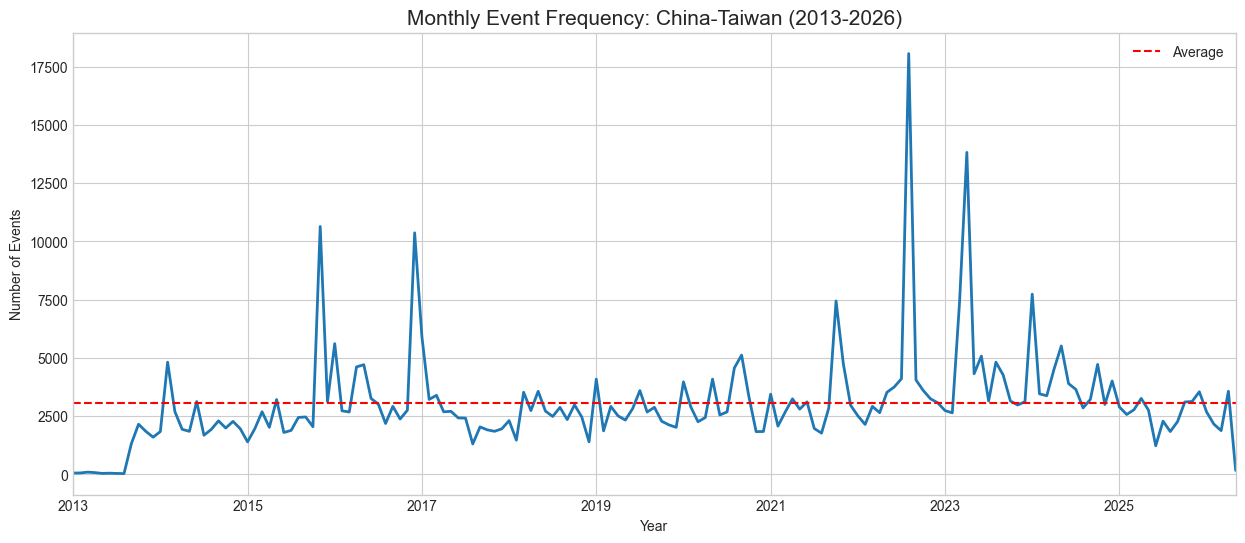

In [16]:
# 1. 날짜 데이터 변환 (Integer -> Datetime)
df['Date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

# 2. 월별 사건 빈도 계산
monthly_counts = df.set_index('Date').resample('M').size()

# 3. 시각화
plt.figure(figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')
monthly_counts.plot(color='#1f77b4', linewidth=2)
plt.title('Monthly Event Frequency: China-Taiwan (2013-2026)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.axhline(monthly_counts.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.show()

#

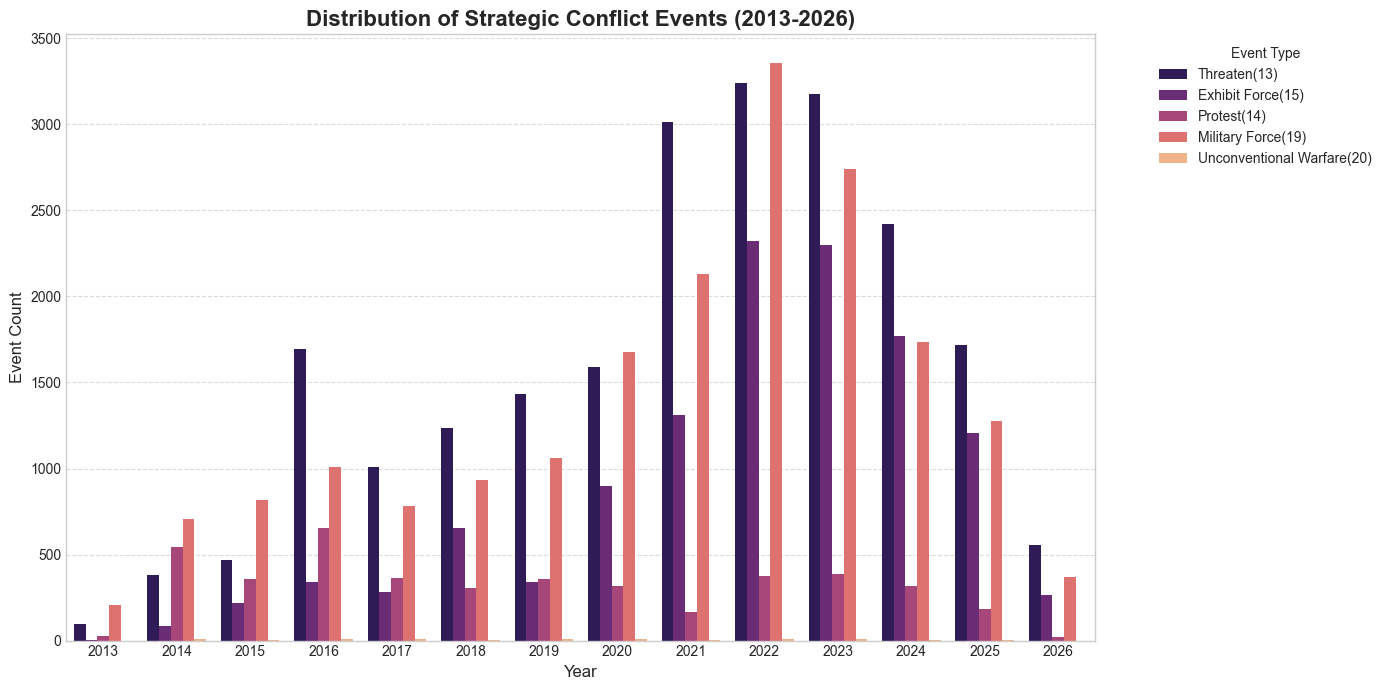

In [19]:
# EventRootCode 추출 (EventCode의 앞 2자리)
df['EventRootCode'] = df['EventCode'].astype(str).str.zfill(3).str[:2]

# 3. 사용자 지정 코드 필터링
selected_codes = ['20', '19', '15', '14', '13']
risk_df = df[df['EventRootCode'].isin(selected_codes)].copy()

# 4. 가독성을 위해 코드 번호를 의미로 변환 (Mapping)
code_map = {
    '20': 'Unconventional Warfare(20)',
    '19': 'Military Force(19)',
    '15': 'Exhibit Force(15)',
    '14': 'Protest(14)',
    '13': 'Threaten(13)'
}
risk_df['EventMeaning'] = risk_df['EventRootCode'].map(code_map)

# 5. 시각화
plt.figure(figsize=(14, 7))
sns.countplot(data=risk_df.sort_values('Year'), x='Year', hue='EventMeaning', palette='magma')

plt.title('Distribution of Strategic Conflict Events (2013-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Event Count', fontsize=12)
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

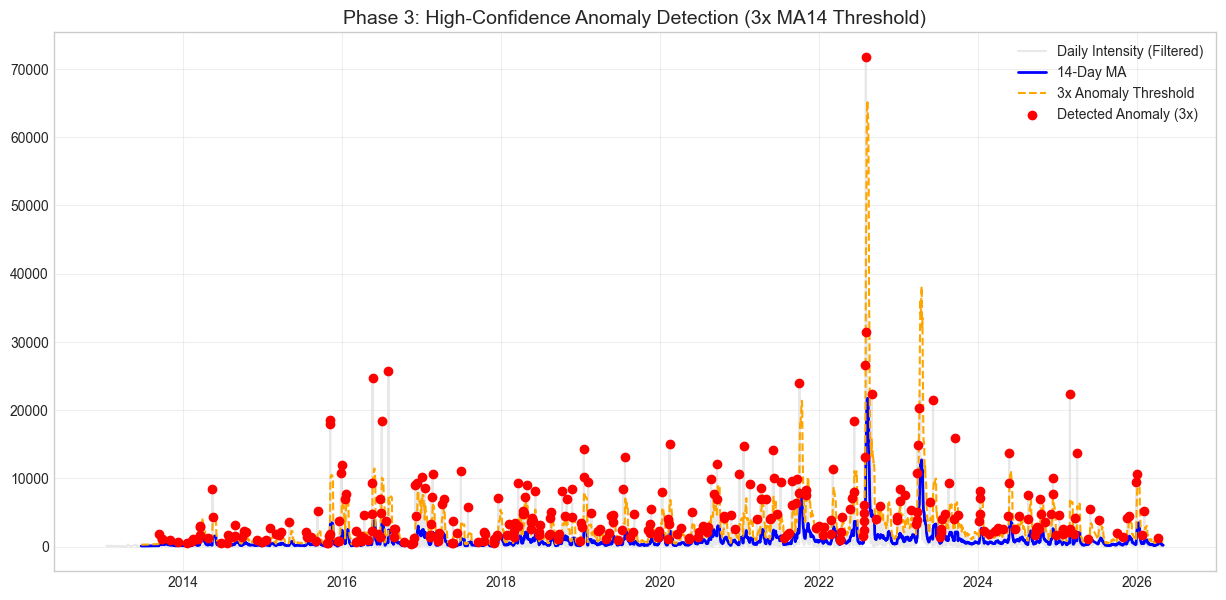

필터링된 핵심 이벤트 수: 57293
검출된 핵심 이상 징후(빨간 점) 개수: 312


In [24]:
# 1. 메모리에 로드된 데이터프레임(df) 복사
target_df = df.copy()

# 2. 이벤트 코드 필터링 (13, 14, 15, 19, 20)
# GDELT EventCode의 앞 2자리를 기준으로 핵심 갈등 코드만 추출
target_df['EventRootCode'] = target_df['EventCode'].astype(str).str.zfill(3).str[:2]
target_codes = ['13', '14', '15', '19', '20']
df_filtered = target_df[target_df['EventRootCode'].isin(target_codes)].copy()

# 3. 날짜 및 지표 계산
if not pd.api.types.is_datetime64_any_dtype(df_filtered['SQLDATE']):
    df_filtered['EventDate'] = pd.to_datetime(df_filtered['SQLDATE'], format='%Y%m%d')
else:
    df_filtered['EventDate'] = df_filtered['SQLDATE']

# 갈등 지수: |골드슈타인 스케일| * 기사 언급량
df_filtered['ConflictIntensity'] = df_filtered['GoldsteinScale'].abs() * df_filtered['NumMentions']

# 4. 일별 집계 및 14일 이동평균 산출
daily = df_filtered.groupby('EventDate')['ConflictIntensity'].sum().reset_index()
daily['MA14'] = daily['ConflictIntensity'].rolling(window=14).mean()

# 5. 이상 징후 포착 기준 상향 (1.5배 -> 3배)
daily['Threshold'] = daily['MA14'] * 3.0
daily['Is_Anomaly'] = daily['ConflictIntensity'] > daily['Threshold']

# 6. 결과 시각화
plt.figure(figsize=(15, 7))
plt.plot(daily['EventDate'], daily['ConflictIntensity'], label='Daily Intensity (Filtered)', color='lightgray', alpha=0.5)
plt.plot(daily['EventDate'], daily['MA14'], label='14-Day MA', color='blue', linewidth=2)
plt.plot(daily['EventDate'], daily['Threshold'], label='3x Anomaly Threshold', color='orange', linestyle='--')

# 임계치를 넘는 핵심 이상 징후만 빨간 점으로 표시
anomalies = daily[daily['Is_Anomaly']]
plt.scatter(anomalies['EventDate'], anomalies['ConflictIntensity'], color='red', label='Detected Anomaly (3x)', zorder=5)

plt.title('Phase 3: High-Confidence Anomaly Detection (3x MA14 Threshold)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 검출 결과 요약 출력
print(f"필터링된 핵심 이벤트 수: {len(df_filtered)}")
print(f"검출된 핵심 이상 징후(빨간 점) 개수: {len(anomalies)}")

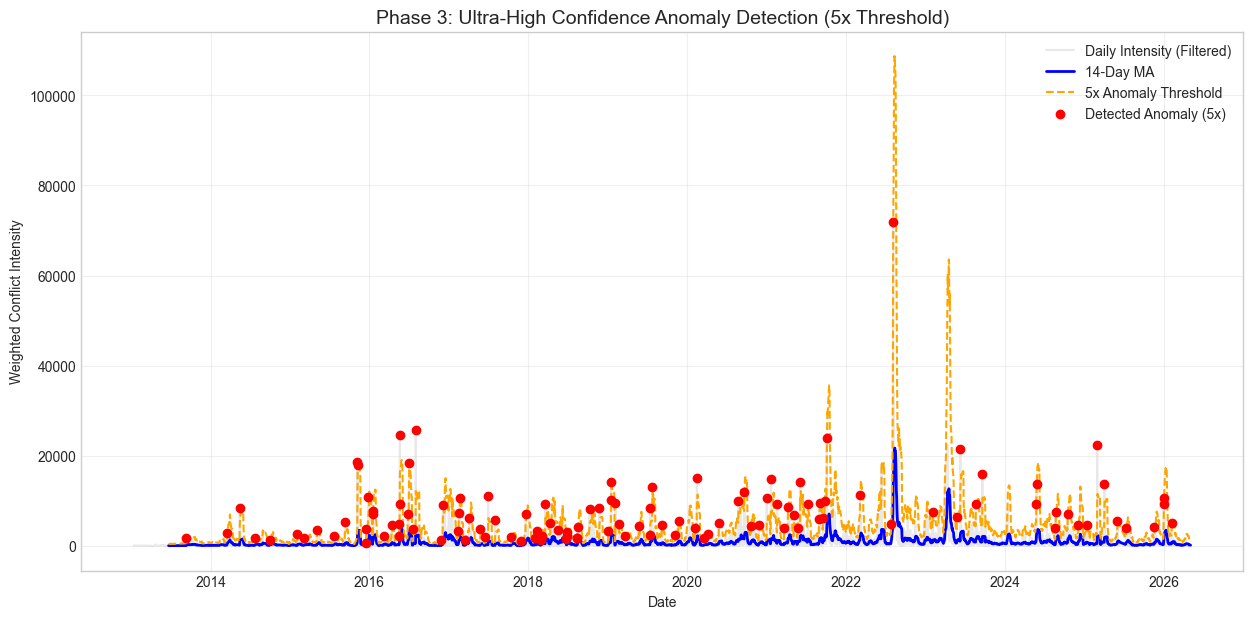

필터링된 핵심 이벤트 수: 57293
검출된 최상위 이상 징후(빨간 점) 개수: 115


In [ ]:
# 기준값 5배 실험


# 1. 메모리에 로드된 데이터프레임(df) 복사[cite: 1]
target_df = df.copy()

# 2. 이벤트 코드 필터링 (13, 14, 15, 19, 20)[cite: 1]
target_df['EventRootCode'] = target_df['EventCode'].astype(str).str.zfill(3).str[:2]
target_codes = ['13', '14', '15', '19', '20']
df_filtered = target_df[target_df['EventRootCode'].isin(target_codes)].copy()

# 3. 날짜 및 지표 계산[cite: 1]
if not pd.api.types.is_datetime64_any_dtype(df_filtered['SQLDATE']):
    df_filtered['EventDate'] = pd.to_datetime(df_filtered['SQLDATE'], format='%Y%m%d')
else:
    df_filtered['EventDate'] = df_filtered['SQLDATE']

# 갈등 지수: |골드슈타인 스케일| * 기사 언급량[cite: 1]
df_filtered['ConflictIntensity'] = df_filtered['GoldsteinScale'].abs() * df_filtered['NumMentions']

# 4. 일별 집계 및 14일 이동평균 산출[cite: 1]
daily = df_filtered.groupby('EventDate')['ConflictIntensity'].sum().reset_index()
daily['MA14'] = daily['ConflictIntensity'].rolling(window=14).mean()

# 5. 이상 징후 포착 기준 상향 (5배)[cite: 1]
daily['Threshold'] = daily['MA14'] * 5.0
daily['Is_Anomaly'] = daily['ConflictIntensity'] > daily['Threshold']

# 6. 결과 시각화[cite: 1]
plt.figure(figsize=(15, 7))
plt.plot(daily['EventDate'], daily['ConflictIntensity'], label='Daily Intensity (Filtered)', color='lightgray', alpha=0.5)
plt.plot(daily['EventDate'], daily['MA14'], label='14-Day MA', color='blue', linewidth=2)
plt.plot(daily['EventDate'], daily['Threshold'], label='5x Anomaly Threshold', color='orange', linestyle='--')

# 5배를 초과하는 지점만 빨간 점으로 표시[cite: 1]
anomalies = daily[daily['Is_Anomaly']]
plt.scatter(anomalies['EventDate'], anomalies['ConflictIntensity'], color='red', label='Detected Anomaly (5x)', zorder=5)

plt.title('Phase 3: Ultra-High Confidence Anomaly Detection (5x Threshold)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Weighted Conflict Intensity')
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()

# 검출 결과 요약 출력
print(f"필터링된 핵심 이벤트 수: {len(df_filtered)}")
print(f"검출된 최상위 이상 징후(빨간 점) 개수: {len(anomalies)}")